In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from collections import OrderedDict

from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, Headings

design = designs.DesignPlanar()
gui = MetalGUI(design)

# if you disable the next line, then you will need to delete a component [<component>.delete()] before recreating it
design.overwrite_enabled = True

  return original_import(name, *args, **kwargs)



In [3]:
from qiskit_metal.qlibrary.qubits.transmon_pocket_6 import TransmonPocket6
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.anchored_path import RouteAnchors
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround

In [16]:
Q1 = TransmonPocket6(design,'Q1',options = dict(
    pos_x = '-1.25mm',
    pos_y = '-0.5mm',
    gds_cell_name = 'Transmon_1',
    hfss_inductance = '14.3nH',
    hfss_capacitance = '0.05fF',
    orientation = '90',
    connection_pads = dict(
        bus_01 = dict(loc_W = 0, loc_H = -1, pad_width = '80um' , pad_gap = '15um'),
        port_01 = dict(loc_W = 0, loc_H = 1, pad_width = '60um' , pad_gap = '15um')
    )
))
Q2 = TransmonPocket6(design,'Q2',options = dict(
    pos_x = '1.25mm',
    pos_y = '0.5mm',
    gds_cell_name = 'Transmon_1',
    hfss_inductance = '15.5nH',
    hfss_capacitance = '0.25fF',
    orientation = '270',
    connection_pads = dict(
        bus_01 = dict(loc_W = 0, loc_H = -1, pad_width = '80um' , pad_gap = '15um'),
        port_01 = dict(loc_W = 0, loc_H = 1, pad_width = '30um' , pad_gap = '15um')
    )
))
gui.rebuild()
gui.autoscale()

In [5]:
from qiskit_metal.qlibrary.lumped.cap_n_interdigital import CapNInterdigital
Q3 = CapNInterdigital(design, 'IDC_1', options = dict(pos_x = '2.945mm',finger_length = '10um',finger_count = '2',cap_distance = '5um',cap_width = '3um',cap_gap= '4um',cap_gap_ground = '6um', orientation = '90'))
Q4 = CapNInterdigital(design, 'IDC_2', options = dict(pos_x = '-2.945mm',finger_length = '10um',finger_count = '2',cap_distance = '5um',cap_width = '3um',cap_gap= '4um',cap_gap_ground = '6um', orientation = '270'))

gui.rebuild()

In [6]:
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
LP1 = LaunchpadWirebond(
    design, 'LP_Q1',
    options=Dict(
        pos_x='-2.5mm',
        pos_y='-1.1mm',
        orientation='0'
    )
)

In [7]:
LP2 = LaunchpadWirebond(
    design, 'LP_Q2',
    options=Dict(
        pos_x='-3mm',
        pos_y='0mm',
        orientation='0'
    )
)

In [8]:
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
ops=dict(fillet='90um')
anchors_Q1 = OrderedDict()
anchors_Q1[0] = np.array([-2.5,0])
anchors_Q1[1] = np.array([-2.5,0.5])
anchors_Q1[2] = np.array([-2.5,1.5])
anchors_Q1[3] = np.array([-2.3,1.0])
anchors_Q1[4] = np.array([-2.1,1.5])
anchors_Q1[5] = np.array([-1.9,1.0])
anchors_Q1[6] = np.array([-1.7,0.6])
anchors_Q1[7] = np.array([-1.7,1.5])
anchors_Q1[8] = np.array([-1.5,0.2])
anchors_Q1[9] = np.array([-1.9,0.2])
options1 = {'pin_inputs':
            {'start_pin': {'component': 'IDC_2', 'pin': 'north_end'},
             'end_pin': {'component': 'Q1', 'pin': 'port_01'}},
            'step_size': '0.05mm',
            'anchors': anchors_Q1,
            **ops
           }

qc1 = RoutePathfinder(design, 'line_Q1', options1)

gui.rebuild()
gui.autoscale()

In [9]:
LP4 = LaunchpadWirebond(
    design, 'LP_Q4',
    options=Dict(
        pos_x='3mm',
        pos_y='0mm',
        orientation='180'
    )
)
gui.rebuild()
gui.autoscale()

In [10]:
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
ops=dict(fillet='90um')
anchors_Q2 = OrderedDict()
anchors_Q2[0] = np.array([2.5,0])
anchors_Q2[1] = np.array([2.5,-0.5])
anchors_Q2[2] = np.array([2.5,-1.5])
anchors_Q2[3] = np.array([2.3,-1.0])
anchors_Q2[4] = np.array([2.1,-1.5])
anchors_Q2[5] = np.array([1.9,-1.0])
anchors_Q2[6] = np.array([1.7,-0.6])
anchors_Q2[7] = np.array([1.7,-1.5])
anchors_Q2[8] = np.array([1.5,-0.2])
anchors_Q2[9] = np.array([1.9,-0.2])
options2 = {'pin_inputs':
            {'start_pin': {'component': 'IDC_1', 'pin': 'north_end'},
             'end_pin': {'component': 'Q2', 'pin': 'port_01'}},
            'step_size': '0.05mm',
            'anchors': anchors_Q2,
            **ops
           }

qc2 = RoutePathfinder(design, 'line_Q2', options2)

gui.rebuild()
gui.autoscale()

In [11]:
LP3 = LaunchpadWirebond(
    design, 'LP_Q3',
    options=Dict(
        pos_x='2.5mm',
        pos_y='1.1mm',
        orientation='180'
    )
)
gui.rebuild()
gui.autoscale()

In [12]:
anchors_Q3 = OrderedDict()
anchors_Q3[0] = np.array([-0.7,-0.5])
anchors_Q3[1] = np.array([-0.625,0.70])
anchors_Q3[2] = np.array([-0.5,0.95])
anchors_Q3[3] = np.array([-0.375,0.5])
anchors_Q3[4] = np.array([-0.25,-1])
anchors_Q3[5] = np.array([-0.125,0.70])
anchors_Q3[6] = np.array([0,1.25])
anchors_Q3[7] = np.array([0.125,0.50])
anchors_Q3[8] = np.array([0.25,-0.7])
anchors_Q3[9] = np.array([0.375,0.5])
options3 = {'pin_inputs':
            {'start_pin': {'component': 'Q1', 'pin': 'bus_01'},
             'end_pin': {'component': 'Q2', 'pin': 'bus_01'}},
            'step_size': '0.05mm',
            'anchors': anchors_Q3,
            **ops
           }

qc1 = RoutePathfinder(design, 'line_Q3', options3)

gui.rebuild()
gui.autoscale()

In [13]:
open_end_1 = OpenToGround(design, 'open_end_1', options=dict(pos_x = '-1.2mm',pos_y = '-0.83mm',orientation = 90))
open_end_2 = OpenToGround(design, 'open_end_2', options=dict(pos_x = '1.2mm',pos_y = '0.83mm',orientation = 270))

In [14]:
charge_Q1 = RoutePathfinder(
    design, 'charge_Q1',
    dict(
        pin_inputs=dict(
            start_pin=dict(component='LP_Q1', pin='tie'),
            end_pin=dict(component = 'open_end_1',pin='open')
        ),
        step_size='0.05mm',
        fillet='20um'
    )
)

charge_Q2 = RoutePathfinder(
    design, 'charge_Q2',
    dict(
        pin_inputs=dict(
            start_pin=dict(component='LP_Q3', pin='tie'),
            end_pin=dict(component = 'open_end_2',pin='open')
        ),
        step_size='0.05mm',
        fillet='20um'
    )
)
gui.rebuild()
gui.autoscale()

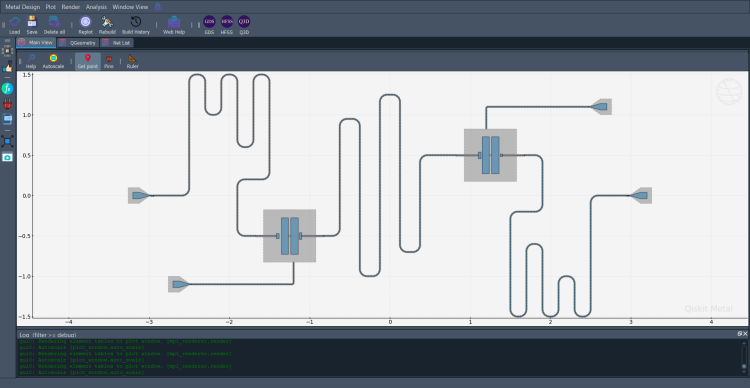

In [15]:
gui.screenshot()

In [16]:
from qiskit_metal.renderers.renderer_ansys.hfss_renderer import QHFSSRenderer

renderer = QHFSSRenderer(design)
renderer.connect_ansys()


INFO 09:53AM [connect_project]: Connecting to Ansys Desktop API...
INFO 09:53AM [load_ansys_project]: 	Opened Ansys App
INFO 09:53AM [load_ansys_project]: 	Opened Ansys Desktop v2022.1.0
INFO 09:53AM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/veera/OneDrive/Documents/Ansoft/
	Project:   Project151
INFO 09:53AM [connect_design]: 	Opened active design
	Design:    Full_System_Analysis_q3d [Solution type: Q3D]
INFO 09:53AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 09:53AM [connect]: 	Connected to project "Project151" and design "Full_System_Analysis_q3d" 😀 

INFO 09:53AM [connect_project]: Connecting to Ansys Desktop API...
INFO 09:53AM [load_ansys_project]: 	Opened Ansys App
INFO 09:53AM [load_ansys_project]: 	Opened Ansys Desktop v2022.1.0
INFO 09:53AM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/veera/OneDrive/Documents/Ansoft/
	Project:   Project151
INFO 09:53AM [connect_design]: 	Opened active design
	Desig

In [17]:
from qiskit_metal.analyses.quantization import LOManalysis
c1 = LOManalysis(design, "q3d")

In [18]:
c1.sim.setup

{'name': 'Setup',
 'reuse_selected_design': True,
 'reuse_setup': True,
 'freq_ghz': 5.0,
 'save_fields': False,
 'enabled': True,
 'max_passes': 15,
 'min_passes': 2,
 'min_converged_passes': 2,
 'percent_error': 0.5,
 'percent_refinement': 30,
 'auto_increase_solution_order': True,
 'solution_order': 'High',
 'solver_type': 'Iterative'}

In [19]:
c1.sim.setup.name = 'Tune_Q_Main'
c1.sim.setup.max_passes = 16
c1.sim.setup.min_converged_passes = 2
c1.sim.setup.percent_error = 0.05
c1.sim.setup

{'name': 'Tune_Q_Main',
 'reuse_selected_design': True,
 'reuse_setup': True,
 'freq_ghz': 5.0,
 'save_fields': False,
 'enabled': True,
 'max_passes': 16,
 'min_passes': 2,
 'min_converged_passes': 2,
 'percent_error': 0.05,
 'percent_refinement': 30,
 'auto_increase_solution_order': True,
 'solution_order': 'High',
 'solver_type': 'Iterative'}

In [20]:
all_comps = list(design.components.keys())
print(all_comps)

['Q1', 'Q2', 'IDC_1', 'IDC_2', 'LP_Q1', 'LP_Q2', 'line_Q1', 'LP_Q4', 'line_Q2', 'LP_Q3', 'line_Q3', 'open_end_1', 'open_end_2', 'charge_Q1', 'charge_Q2']


In [21]:
c1.sim.run(
     name="Full_System_Analysis",
     components=['Q1','line_Q1', 'LP_Q2','IDC_2'],
     open_terminations=[]
 )

INFO 09:53AM [connect_project]: Connecting to Ansys Desktop API...
INFO 09:53AM [load_ansys_project]: 	Opened Ansys App
INFO 09:53AM [load_ansys_project]: 	Opened Ansys Desktop v2022.1.0
INFO 09:53AM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/veera/OneDrive/Documents/Ansoft/
	Project:   Project151
INFO 09:53AM [connect_design]: 	Opened active design
	Design:    Full_System_Analysis_q3d [Solution type: Q3D]
INFO 09:53AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 09:53AM [connect]: 	Connected to project "Project151" and design "Full_System_Analysis_q3d" 😀 

INFO 09:53AM [connect_design]: 	Opened active design
	Design:    Full_System_Analysis_q3d [Solution type: Q3D]
INFO 09:54AM [__del__]: Disconnected from Ansys HFSS
INFO 09:54AM [get_setup]: 	Opened setup `Tune_Q_Main`  (<class 'pyEPR.ansys.AnsysQ3DSetup'>)
INFO 09:54AM [analyze]: Analyzing setup Tune_Q_Main
INFO 10:02AM [get_matrix]: Exporting matrix data to (C:\Users\veera\App

In [22]:
c1.sim.capacitance_matrix

,bus_01_connector_pad_Q1,cap_body_0_IDC_2,cap_body_1_IDC_2,pad_bot_Q1,pad_top_Q1
bus_01_connector_pad_Q1,1620.89051,-48.59037,-1331.42074,-58.09995,-48.06413
cap_body_0_IDC_2,-48.59037,49.92038,-1.02071,-0.00761,-0.00923
cap_body_1_IDC_2,-1331.42074,-1.02071,1344.57452,-1.37573,-8.71758
pad_bot_Q1,-58.09995,-0.00761,-1.37573,95.34825,-34.60430
pad_top_Q1,-48.06413,-0.00923,-8.71758,-34.60430,92.69420


In [23]:
# # Get the matrix
# cmat = c1.sim.capacitance_matrix

# # Name of the row/column you want to remove
# drop_label = 'cap_body_0_IDC_2'

# # Drop it from both rows and columns
# cmat_trimmed = cmat.drop(index=drop_label, columns=drop_label)

# c1.sim.capacitance_matrix = cmat_trimmed

In [24]:
# # Get the matrix
cmat = c1.sim.capacitance_matrix

# # Name of the row/column you want to remove
drop_label = 'cap_body_0_IDC_2'

# # Drop it from both rows and columns
cmat_trimmed = cmat.drop(index=drop_label, columns=drop_label)

c1.sim.capacitance_matrix = cmat_trimmed

In [25]:
# capacitance_matrix can stay as a DataFrame (for display/bookkeeping)
correct_order = ['bus_01_connector_pad_Q1', 'pad_bot_Q1', 'pad_top_Q1', 'cap_body_1_IDC_2']
cmat_ordered = cmat_trimmed.loc[correct_order, correct_order]
c1.sim.capacitance_matrix = cmat_ordered
cmat_ordered_F = cmat_ordered * 1e-15
# capacitance_all_passes needs plain NumPy arrays, not DataFrames
for idx in c1.sim.capacitance_all_passes.keys():
    c1.sim.capacitance_all_passes[idx] = cmat_ordered_F.values   # <-- .values here

# Setup
c1.setup.junctions = Dict({'Lj': 15.5, 'Cj': 0.25})
c1.setup.freq_readout = 7.48
c1.setup.freq_bus = []

c1.run_lom()
c1.lumped_oscillator_all

[1, 2] [3]
Predicted Values

Transmon Properties
f_Q 4.732004 [GHz]
EC 303.119035 [MHz]
EJ 10.541652 [GHz]
alpha -361.419424 [MHz]
dispersion 201.645923 [KHz]
Lq 15.493750 [nH]
Cq 63.903041 [fF]
T1 841.241549 [us]

**Coupling Properties**

tCqbus1 -3.787868 [fF]
gbus1_in_MHz -56.393206 [MHz]
χ_bus1 -0.284914 [MHz]
1/T1bus1 189.190540 [Hz]
T1bus1 841.241549 [us]
Bus-Bus Couplings


,fQ,EC,EJ,alpha,dispersion,gbus,chi_in_MHz,χr MHz,gr MHz
1,4.732004,303.119035,10.541652,-361.419424,201.645923,[-56.39320579367485],[-0.2849140496766465],0.284914,56.393206
2,4.732004,303.119035,10.541652,-361.419424,201.645923,[-56.39320579367485],[-0.2849140496766465],0.284914,56.393206
3,4.732004,303.119035,10.541652,-361.419424,201.645923,[-56.39320579367485],[-0.2849140496766465],0.284914,56.393206
4,4.732004,303.119035,10.541652,-361.419424,201.645923,[-56.39320579367485],[-0.2849140496766465],0.284914,56.393206
5,4.732004,303.119035,10.541652,-361.419424,201.645923,[-56.39320579367485],[-0.2849140496766465],0.284914,56.393206
6,4.732004,303.119035,10.541652,-361.419424,201.645923,[-56.39320579367485],[-0.2849140496766465],0.284914,56.393206
7,4.732004,303.119035,10.541652,-361.419424,201.645923,[-56.39320579367485],[-0.2849140496766465],0.284914,56.393206
8,4.732004,303.119035,10.541652,-361.419424,201.645923,[-56.39320579367485],[-0.2849140496766465],0.284914,56.393206
9,4.732004,303.119035,10.541652,-361.419424,201.645923,[-56.39320579367485],[-0.2849140496766465],0.284914,56.393206
10,4.732004,303.119035,10.541652,-361.419424,201.645923,[-56.39320579367485],[-0.2849140496766465],0.284914,56.393206


10:02AM 57s CRITICAL [_qt_message_handler]: line: 0, func: None(), file: None  CRITICAL: QEventDispatcherWin32::wakeUp: Failed to post a message (Not enough quota is available to process this command.)

